In [1]:
import pandas as pd

In [2]:
import pandas as pd

df = pd.read_csv("../dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [9]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [10]:
df["TotalCharges"].value_counts().head(10)

TotalCharges
20.2     11
         11
19.75     9
19.65     8
19.9      8
20.05     8
19.55     7
45.3      7
19.45     6
20.25     6
Name: count, dtype: int64

In [11]:
df["TotalCharges"].dtype

dtype('O')

In [12]:
df["TotalCharges"].str.strip().eq("").sum()

np.int64(11)

In [13]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].head(10)

,tenure,MonthlyCharges,TotalCharges
0,1,29.85,29.85
1,34,56.95,1889.5
2,2,53.85,108.15
3,45,42.30,1840.75
4,2,70.70,151.65
5,8,99.65,820.5
6,22,89.10,1949.4
7,10,29.75,301.9
8,28,104.80,3046.05
9,62,56.15,3487.95


In [14]:
df[["tenure", "MonthlyCharges"]].describe()

,tenure,MonthlyCharges
count,7043.000000,7043.000000
mean,32.371149,64.761692
std,24.559481,30.090047
min,0.000000,18.250000
25%,9.000000,35.500000
50%,29.000000,70.350000
75%,55.000000,89.850000
max,72.000000,118.750000


In [15]:
df["TotalCharges"] = df["TotalCharges"].str.strip()

In [16]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [17]:
df["TotalCharges"].dtype

dtype('float64')

In [18]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [19]:
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [20]:
df = df.dropna(subset=["TotalCharges"])

In [21]:
df.shape

(7032, 21)

In [22]:
df.isnull().sum().sum()

np.int64(0)

In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
df.to_csv("../dataset/telco_churn_cleaned.csv", index=False)

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df["Churn"].value_counts()

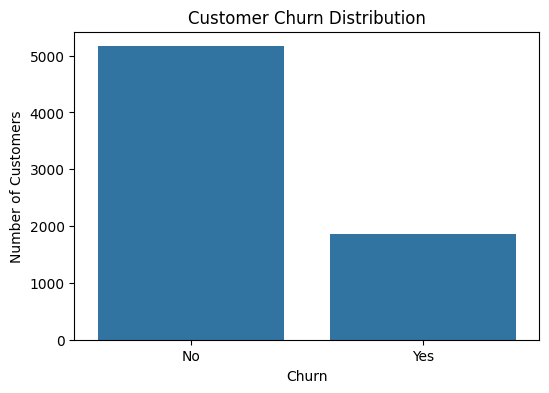

In [26]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

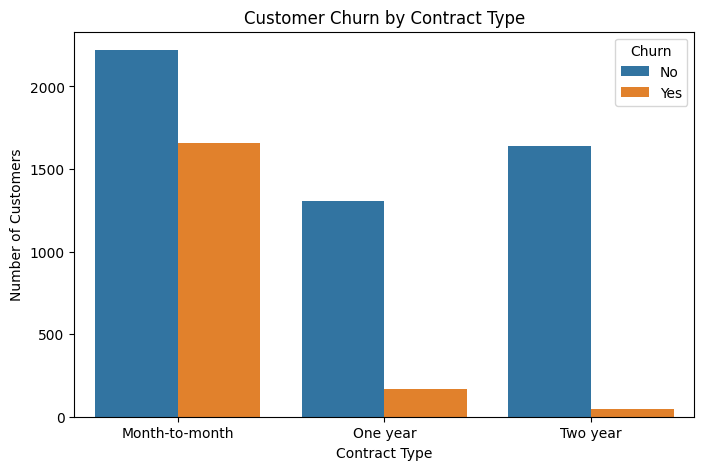

In [27]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

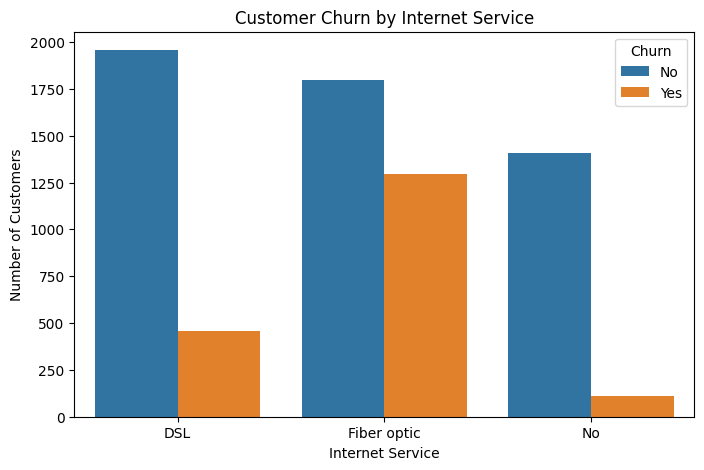

In [28]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="InternetService", hue="Churn")

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

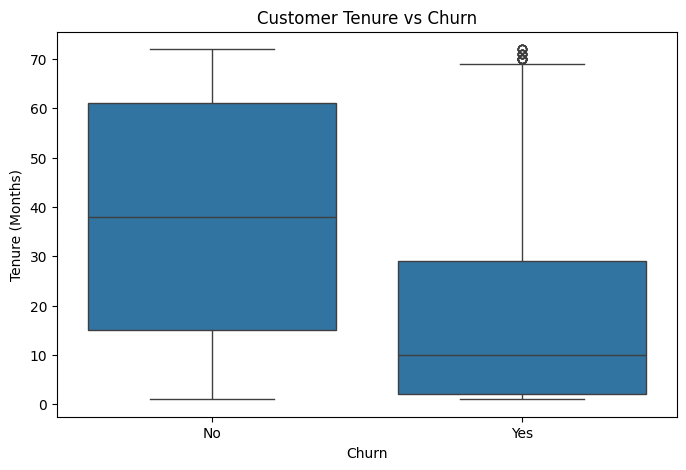

In [29]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Churn", y="tenure")

plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

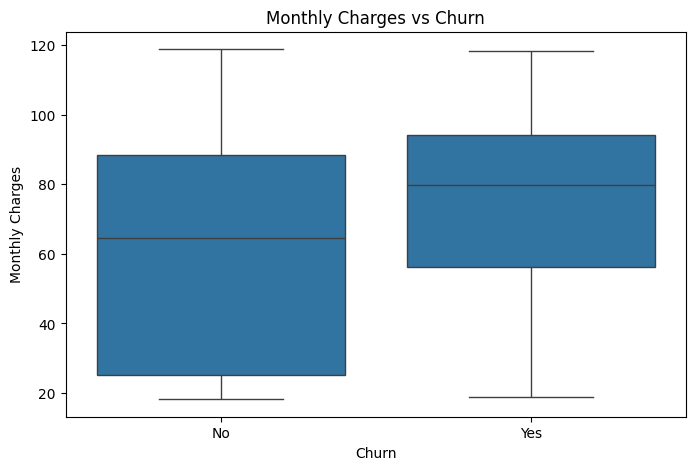

In [30]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()


In [31]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


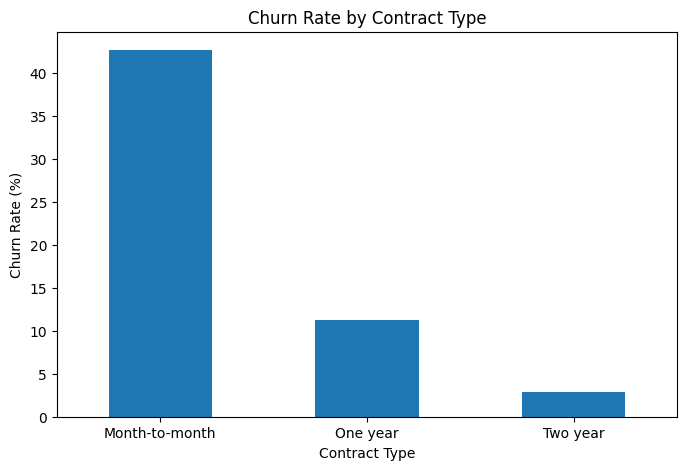

In [32]:
contract_churn["Yes"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [33]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


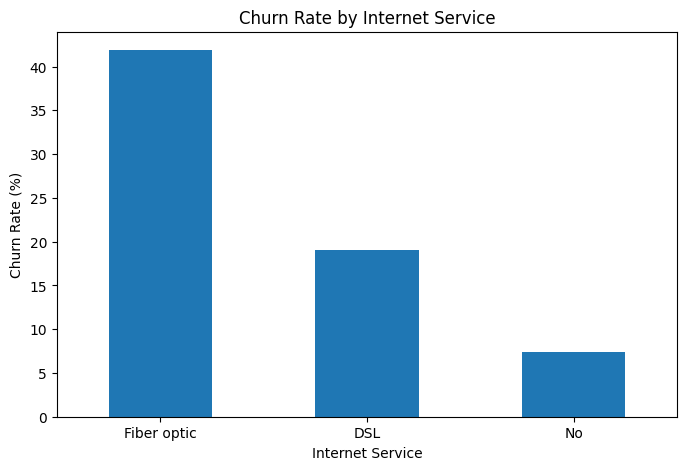

In [34]:
internet_churn["Yes"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [35]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


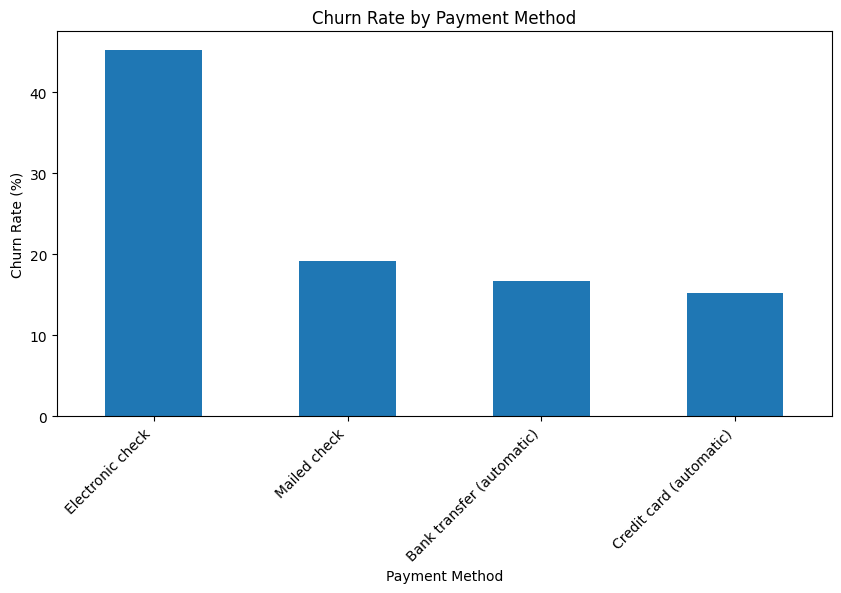

In [36]:
payment_churn["Yes"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.show()

In [37]:
senior_churn = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

senior_churn

Churn,No,Yes
SeniorCitizen,,
0,76.349745,23.650255
1,58.318739,41.681261


In [38]:
df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].mean()

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.650010,61.307408,2555.344141
Yes,17.979133,74.441332,1531.796094


In [39]:
df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].median()

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,38.0,64.45,1683.60
Yes,10.0,79.65,703.55


In [40]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].corr()

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.246862,0.825880
MonthlyCharges,0.246862,1.000000,0.651065
TotalCharges,0.825880,0.651065,1.000000


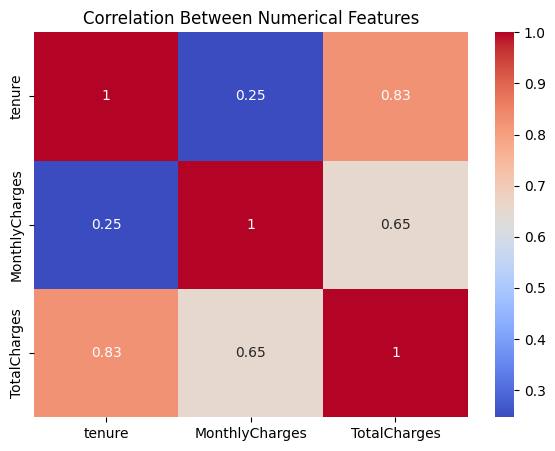

In [41]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    df[["tenure", "MonthlyCharges", "TotalCharges"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Numerical Features")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../visualizations/churn_distribution.png'

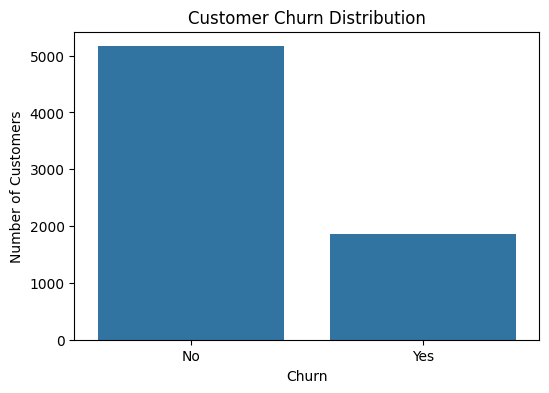

In [42]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.savefig("../visualizations/churn_distribution.png", bbox_inches="tight")

plt.show()

In [43]:
import os
print(os.getcwd())

C:\Users\SHARMILA\OneDrive\Documents\Customer_Churn_Data_Science_Project\notebooks


In [44]:
import os

os.makedirs("../visualizations", exist_ok=True)

print("Visualizations folder is ready!")

Visualizations folder is ready!


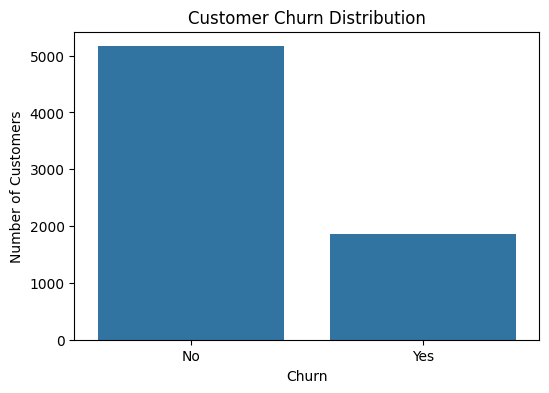

In [45]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.savefig("../visualizations/churn_distribution.png", bbox_inches="tight")

plt.show()

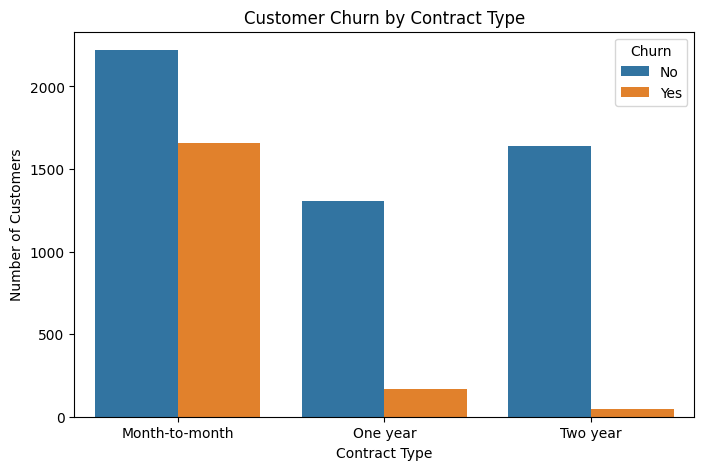

In [46]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.savefig("../visualizations/churn_by_contract.png", bbox_inches="tight")

plt.show()

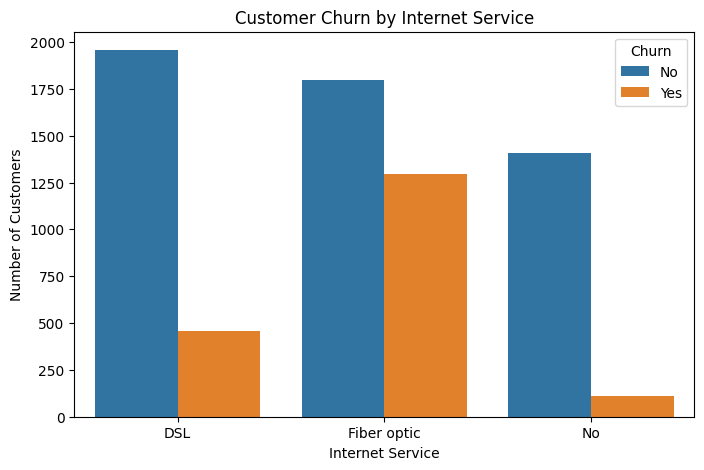

In [47]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="InternetService", hue="Churn")

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.savefig("../visualizations/churn_by_internet_service.png", bbox_inches="tight")

plt.show()

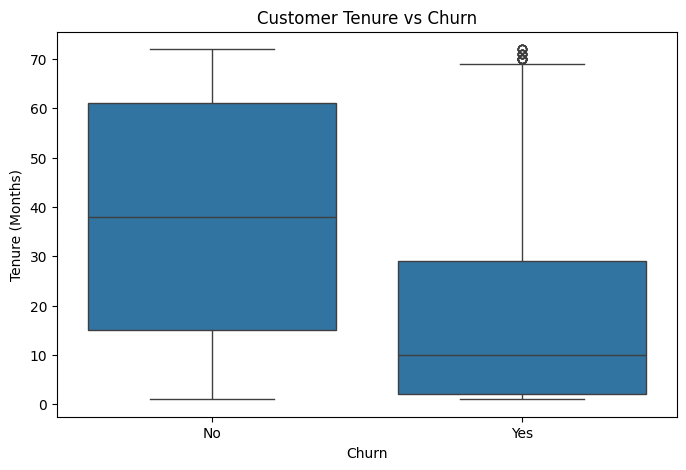

In [48]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Churn", y="tenure")

plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.savefig("../visualizations/tenure_vs_churn.png", bbox_inches="tight")

plt.show()

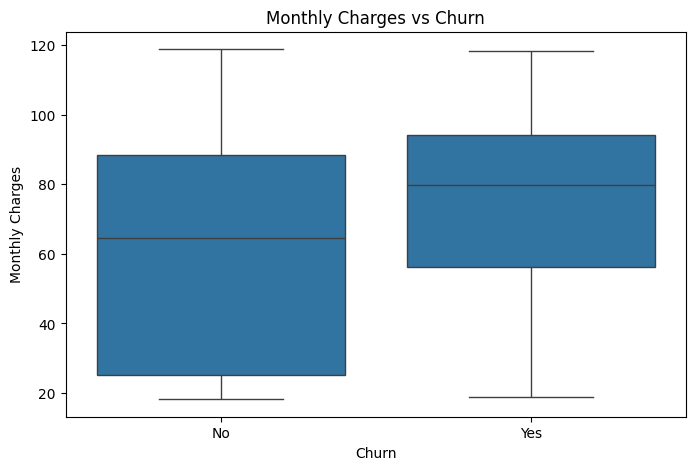

In [49]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.savefig("../visualizations/monthly_charges_vs_churn.png", bbox_inches="tight")

plt.show()

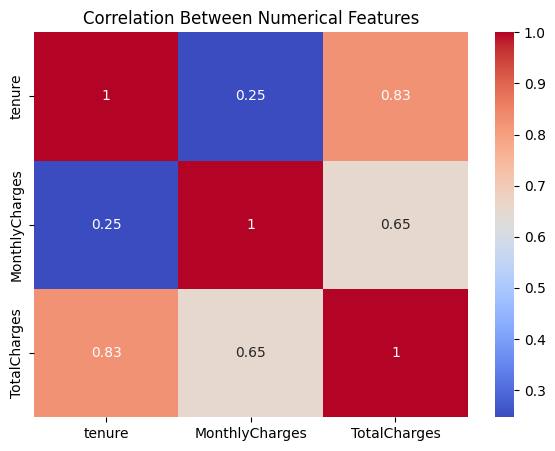

In [50]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    df[["tenure", "MonthlyCharges", "TotalCharges"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Numerical Features")

plt.savefig("../visualizations/correlation_heatmap.png", bbox_inches="tight")

plt.show()

In [51]:
ml_df = df.copy()

In [52]:
No  → 0
Yes → 1

SyntaxError: invalid character '→' (U+2192) (396232439.py, line 1)

In [53]:
ml_df["Churn"] = ml_df["Churn"].map({"No": 0, "Yes": 1})

In [54]:
ml_df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [55]:
ml_df = ml_df.drop("customerID", axis=1)

In [56]:
ml_df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [57]:
X = ml_df.drop("Churn", axis=1)
y = ml_df["Churn"]

In [58]:
X.shape

(7032, 19)

In [59]:
y.shape

(7032,)

In [60]:
X.select_dtypes(include="object").columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [61]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [62]:
X_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [63]:
X_encoded.shape

(7032, 30)

In [64]:
X_encoded = X_encoded.astype(int)

In [65]:
X_encoded.dtypes.value_counts()

int64    30
Name: count, dtype: int64

In [66]:
from sklearn.model_selection import train_test_split

In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [68]:
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (5625, 30)
Testing features: (1407, 30)
Training target: (5625,)
Testing target: (1407,)


In [69]:
from sklearn.preprocessing import StandardScaler

In [70]:
scaler = StandardScaler()

In [71]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [72]:
print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (5625, 30)
Testing data shape: (1407, 30)


In [73]:
from sklearn.linear_model import LogisticRegression

In [74]:
logistic_model = LogisticRegression(max_iter=1000)

In [75]:
logistic_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [76]:
y_pred = logistic_model.predict(X_test_scaled)

In [77]:
y_pred[:20]

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0])

In [78]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.8038379530916845
Accuracy (%): 80.38379530916845


In [79]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [80]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[916 117]
 [159 215]]


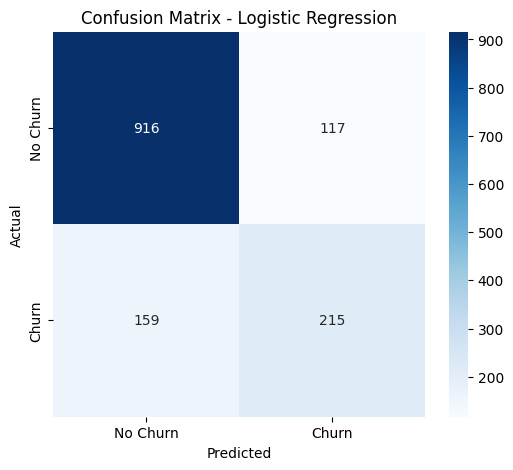

In [81]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [82]:
y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

In [83]:
y_prob[:10]

array([0.01760375, 0.59278458, 0.00479665, 0.20160114, 0.09961258,
       0.47487779, 0.02649958, 0.16564435, 0.68179166, 0.01541396])

In [84]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8357206827111731


In [85]:
from sklearn.ensemble import RandomForestClassifier

In [86]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [87]:
rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [88]:
rf_pred = rf_model.predict(X_test)

In [89]:
rf_pred[:20]

array([0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0])

In [90]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Accuracy (%):", rf_accuracy * 100)

Random Forest Accuracy: 0.7896233120113717
Random Forest Accuracy (%): 78.96233120113718


In [91]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [92]:
rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest ROC-AUC:", rf_auc)

Random Forest ROC-AUC: 0.8176408467109452


In [93]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy, rf_accuracy],
    "ROC-AUC": [roc_auc, rf_auc]
})

model_comparison

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.803838,0.835721
1,Random Forest,0.789623,0.817641


In [94]:
model_comparison

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.803838,0.835721
1,Random Forest,0.789623,0.817641


In [95]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [96]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": logistic_model.coef_[0]
})

feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

feature_importance.head(10)

,Feature,Coefficient,Absolute_Coefficient
1,tenure,-1.340640,1.340640
2,MonthlyCharges,-0.661070,0.661070
10,InternetService_Fiber optic,0.647935,0.647935
3,TotalCharges,0.635002,0.635002
25,Contract_Two year,-0.602742,0.602742
24,Contract_One year,-0.312854,0.312854
21,StreamingTV_Yes,0.218757,0.218757
23,StreamingMovies_Yes,0.205692,0.205692
9,MultipleLines_Yes,0.199441,0.199441
28,PaymentMethod_Electronic check,0.184252,0.184252


In [97]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": logistic_model.coef_[0]
})

feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

feature_importance.head(10)

,Feature,Coefficient,Absolute_Coefficient
1,tenure,-1.340640,1.340640
2,MonthlyCharges,-0.661070,0.661070
10,InternetService_Fiber optic,0.647935,0.647935
3,TotalCharges,0.635002,0.635002
25,Contract_Two year,-0.602742,0.602742
24,Contract_One year,-0.312854,0.312854
21,StreamingTV_Yes,0.218757,0.218757
23,StreamingMovies_Yes,0.205692,0.205692
9,MultipleLines_Yes,0.199441,0.199441
28,PaymentMethod_Electronic check,0.184252,0.184252


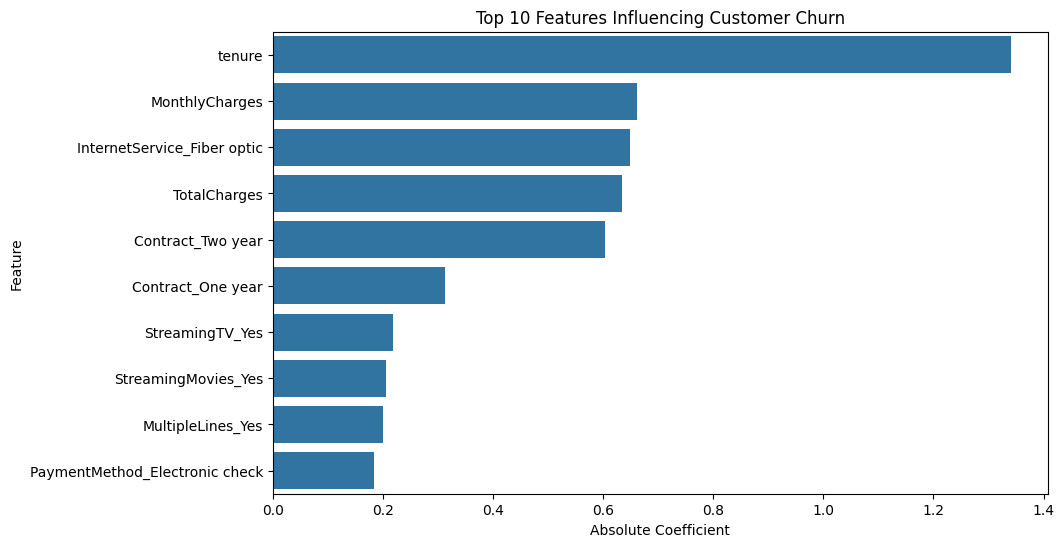

In [98]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Absolute_Coefficient",
    y="Feature"
)

plt.title("Top 10 Features Influencing Customer Churn")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")

plt.show()

In [99]:
import joblib

In [100]:
joblib.dump(
    logistic_model,
    "../models/logistic_regression_churn.pkl"
)

['../models/logistic_regression_churn.pkl']

In [101]:
joblib.dump(
    scaler,
    "../models/churn_scaler.pkl"
)

['../models/churn_scaler.pkl']

In [102]:
joblib.dump(
    X_encoded.columns.tolist(),
    "../models/feature_names.pkl"
)

['../models/feature_names.pkl']

In [103]:
def predict_churn(customer_data):

    # Convert customer data into DataFrame
    customer_df = pd.DataFrame([customer_data])

    # Encode categorical variables
    customer_encoded = pd.get_dummies(customer_df, drop_first=True)

    # Make sure the columns are the same as training data
    customer_encoded = customer_encoded.reindex(
        columns=X_encoded.columns,
        fill_value=0
    )

    # Scale the data
    customer_scaled = scaler.transform(customer_encoded)

    # Make prediction
    prediction = logistic_model.predict(customer_scaled)[0]

    # Get probability
    probability = logistic_model.predict_proba(customer_scaled)[0][1]

    if prediction == 1:
        result = "Yes - Customer may churn"
    else:
        result = "No - Customer is likely to stay"

    print("Prediction:", result)
    print("Churn Probability:", round(probability * 100, 2), "%")

    return prediction, probability

In [104]:
customer = {
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "No",
    "tenure": 5,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "Yes",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 90,
    "TotalCharges": 450
}

In [105]:
predict_churn(customer)

Prediction: No - Customer is likely to stay
Churn Probability: 16.78 %


(np.int64(0), np.float64(0.16776327988291836))

In [106]:
churn_rate = df["Churn"].value_counts(normalize=True) * 100

print("Churn Rate:")
print(churn_rate)

Churn Rate:
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


In [107]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


In [108]:
tenure_churn = df.groupby("Churn")["tenure"].mean()

tenure_churn

Churn
No     37.650010
Yes    17.979133
Name: tenure, dtype: float64

In [109]:
monthly_charges_churn = df.groupby("Churn")["MonthlyCharges"].mean()

monthly_charges_churn

Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [110]:
df.to_csv("../data/customer_churn_cleaned.csv", index=False)

OSError: Cannot save file into a non-existent directory: '..\data'

In [111]:
import os

os.makedirs("../data", exist_ok=True)

print("Data folder is ready!")

Data folder is ready!


In [112]:
df.to_csv("../data/customer_churn_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [113]:
import os

print(os.path.exists("../data/customer_churn_cleaned.csv"))

True
